# 06 — Explainability, Fairness and Transferability

**Project:** 30-Day Readmission Risk in Diabetic Inpatients
**Notebook 6 of 6**

---

Notebook 05 settled which model I am carrying forward. Gradient boosting caught
1,067 readmissions of 2,179 at a review budget of 5,486 patients, against 972 for
ranking by prior inpatient admissions alone — a gain of 95 patients with a bootstrap
CI of 57 to 137, and the only model whose advantage over that heuristic I could
convincingly establish. It was also the best calibrated of the three, with no flagged
bands.

But that calibration result was aggregate, and notebook 04 is the reason I do not
trust aggregate numbers here. My logistic model's mean absolute calibration gap was
0.0071 across deciles — excellent by any standard — and underneath it one group was
being scored 30% below their observed rate while the top band over-predicted almost
everywhere. The errors cancelled. A clean overall figure told me nothing.

So this notebook has three jobs, and the first one gates the others:

1. **Repeat notebook 04's subgroup checks on the boosting model.** Discrimination,
   flag rates and calibration, group by group. If the "Other" under-scoring survives
   the change of algorithm, that is a data problem rather than a model problem, and
   the tiered design does not proceed.
2. **Work out what the model is actually using**, so that a clinician reading a flag
   can be told why it fired.
3. **Write up the two things I have been deferring** — a clinician-facing summary of
   what this model is and is not, and the transferability question I have been
   promising since notebook 01.

Nothing new gets fitted beyond rebuilding the notebook 05 model, and no conclusion
from earlier notebooks gets revisited unless this one contradicts it.

---
## 0. Setup: rebuilding the notebook 05 model

Notebook 05 did not save its fitted boosting model, so I rebuild it here. That is
not ideal and I would save it properly if I were starting over, but rebuilding is
cheap and it has one advantage: if the model I get here does not reproduce notebook
05's numbers exactly, I find out immediately rather than quietly analysing a
different model than the one I wrote up.

All of the loading and preprocessing below is lifted unchanged from notebook 05,
which in turn lifted it from notebook 03. It has to match exactly or nothing
downstream is comparable.

In [1]:
# Imports, matched to notebooks 03 and 05 so the split and the model reproduce exactly
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance, partial_dependence
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from statsmodels.stats.proportion import proportion_confint

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
DATA_DIR = "../data"

In [2]:
# Load and transform exactly as notebooks 03 and 05 did, or the feature matrix will not match
df = pd.read_csv(f"{DATA_DIR}/processed/cohort_eda.csv", low_memory=False)

def diabetes_detail(code):
    s = str(code)
    if len(s) < 6:
        return "Diabetes, unspecified"
    return "Diabetes, uncomplicated" if s[4] == "0" else "Diabetes, complicated"

for col in ["diag_2", "diag_3"]:
    grp = col + "_group"
    mask = df[grp] == "Diabetes"
    df.loc[mask, grp] = df.loc[mask, col].apply(diabetes_detail)

EXCLUDE = {"encounter_id", "patient_nbr", "readmitted", "target",
           "diag_1", "diag_2", "diag_3", "under_20"}
FEATURES = [c for c in df.columns if c not in EXCLUDE]

CODED_CATEGORICAL = ["admission_type_id", "discharge_disposition_id", "admission_source_id"]
NUMERIC = [c for c in FEATURES
           if pd.api.types.is_numeric_dtype(df[c]) and c not in CODED_CATEGORICAL]
CATEGORICAL = [c for c in FEATURES if c not in NUMERIC]

for c in CODED_CATEGORICAL:
    df[c] = df[c].astype(str)

for col in ["A1Cresult", "max_glu_serum"]:
    flag = col.lower().replace("result", "") + "_measured"
    df[flag] = df[col].notna().astype(int)
    df[col] = df[col].fillna("not_measured")
NUMERIC += ["a1c_measured", "max_glu_serum_measured"]

MIN_LEVEL_N = 100

def collapse_rare(series, min_n=MIN_LEVEL_N, label="Other_rare"):
    vc = series.value_counts(dropna=False)
    keep = set(vc[vc >= min_n].index)
    return series.where(series.isin(keep), label)

for col in CATEGORICAL:
    df[col] = collapse_rare(df[col].fillna("Unknown"))

print(f"Numeric: {len(NUMERIC)}   Categorical: {len(CATEGORICAL)}   Total: {len(NUMERIC) + len(CATEGORICAL)}")

Numeric: 10   Categorical: 27   Total: 37


In [3]:
# Rebuild the split and confirm it is still the same test set notebooks 04 and 05 used
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, df["target"], groups=df["patient_nbr"]))

train = df.iloc[train_idx].copy()
test  = df.iloc[test_idx].copy()

nb04 = pd.read_csv(f"{DATA_DIR}/processed/test_predictions.csv")
assert set(test["encounter_id"]) == set(nb04["encounter_id"]), \
    "SPLIT DOES NOT MATCH the earlier notebooks - stop here"

y_train = train["target"].values
y_test  = test["target"].values

print(f"Train: {len(train):,} encounters   Test: {len(test):,} encounters")
print("Split matches notebooks 04 and 05.")

Train: 79,682 encounters   Test: 19,634 encounters
Split matches notebooks 04 and 05.


In [4]:
# Rebuild the boosting model from notebook 05 and check it reproduces the same figures
baseline = joblib.load("../models/baseline_logreg.joblib")
prep = baseline.named_steps["prep"]

X_train = prep.transform(train)
X_test  = prep.transform(test)
if hasattr(X_train, "toarray"):
    X_train, X_test = X_train.toarray(), X_test.toarray()

gb = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.05, max_leaf_nodes=31,
    min_samples_leaf=50, l2_regularization=1.0,
    early_stopping=True, validation_fraction=0.15,
    random_state=RANDOM_STATE,
)
gb.fit(X_train, y_train)
prob_gb = gb.predict_proba(X_test)[:, 1]

print(f"Rounds: {gb.n_iter_}  (notebook 05: 108)")
print(f"ROC AUC: {roc_auc_score(y_test, prob_gb):.3f}  (notebook 05: 0.670)")
print(f"Brier:   {brier_score_loss(y_test, prob_gb):.4f}  (notebook 05: 0.0939)")

Rounds: 108  (notebook 05: 108)
ROC AUC: 0.670  (notebook 05: 0.670)
Brier:   0.0939  (notebook 05: 0.0939)


In [5]:
# Save the model and its test predictions so this work never has to be refitted again
import os
os.makedirs("../models", exist_ok=True)
joblib.dump(gb, "../models/gradient_boosting.joblib")

preds = test[["encounter_id", "patient_nbr", "target", "age", "race",
              "gender", "under_20", "payer_code"]].copy()
preds["prob"] = prob_gb
preds.to_csv(f"{DATA_DIR}/processed/test_predictions_gb.csv", index=False)

print(f"Saved model and {len(preds):,} boosting predictions.")

Saved model and 19,634 boosting predictions.


One thing that does not carry across from notebook 04: the threshold. 0.125 was the
point where the logistic model's F1 peaked, and it flagged 27.9% of discharges. The
boosting model spreads its probabilities differently, so the same number will flag a
different share of the ward.

Since every comparison in notebook 05 was made at a fixed review budget rather than
a fixed threshold, I keep the budget constant here and work backwards to whatever
threshold produces it. That keeps the workload identical to what notebook 04
committed to, which is the thing a discharge team actually cares about.

In [6]:
# Find the boosting threshold that flags the same number of patients notebook 04 committed to
BUDGET = 5486

threshold_gb = float(np.sort(prob_gb)[::-1][BUDGET - 1])
flag_gb = (prob_gb >= threshold_gb).astype(int)

tp = int(((flag_gb == 1) & (y_test == 1)).sum())
fp = int(((flag_gb == 1) & (y_test == 0)).sum())
fn = int(((flag_gb == 0) & (y_test == 1)).sum())

print(f"Budget-matched threshold: {threshold_gb:.4f}   (logistic model used 0.125)")
print(f"Flagged:   {tp + fp:,} of {len(y_test):,} ({100*(tp+fp)/len(y_test):.1f}%)")
print(f"Caught:    {tp} of {tp + fn} ({100*tp/(tp+fn):.1f}%)")
print(f"Precision: {100*tp/(tp+fp):.1f}%")

Budget-matched threshold: 0.1287   (logistic model used 0.125)
Flagged:   5,486 of 19,634 (27.9%)
Caught:    1067 of 2179 (49.0%)
Precision: 19.4%


To compare fairly against notebook 04, I hold the review budget fixed rather than the threshold. The logistic model flagged 27.9% of discharges at a threshold of 0.125; the boosting model reaches that same 27.9% at 0.1287. The two numbers are not comparable directly because each model puts its probabilities on a slightly different scale, but the operational question is the same either way: if a ward can review this many patients before discharge, which patients should they be?

At that budget the boosting model catches 1,067 of 2,179 readmissions, 49.0%, at 19.4% precision. That reproduces notebook 05 and confirms the threshold solve is doing what I intended.

Precision of 19.4% means roughly four in five flagged patients would not have come back within thirty days. Against an 11.1% base rate that is still a lift of about 1.75x, and for a discharge-planning conversation the cost of being wrong is low. But it is the number to keep in front of me for the rest of this notebook, because every fairness question that follows is a question about which patients are in that flagged 27.9% and which are not.

---
## 1. Does the boosting model discriminate equally across groups?

This repeats notebook 04's section 3 on the new model. There, the finding was not
about race or sex at all — it was age. Discrimination fell steadily as age rose,
from 0.731 in the 30s to 0.596 in the over-90s, with non-overlapping intervals, and
the base rate moved the opposite way. The model was worst exactly where the risk was
highest.

My expectation is that boosting does not fix this, because I concluded the cause was
missing information rather than model form — frailty, cognition, who manages the
insulin at home. If a different algorithm closes that gap, my explanation was wrong
and I need to say so.

In [7]:
# Subgroup AUC with bootstrap intervals, using the fast rank-based AUC so this completes quickly
MIN_EVENTS = 20
N_BOOT = 500
rng = np.random.default_rng(RANDOM_STATE)

gbp = test[["encounter_id", "age", "race", "gender", "under_20"]].copy()
gbp["target"] = y_test
gbp["prob"] = prob_gb

def fast_auc(yt, yp):
    """AUC via the Mann-Whitney U identity - equivalent to roc_auc_score, much faster."""
    n_pos = yt.sum()
    n_neg = len(yt) - n_pos
    if n_pos == 0 or n_neg == 0:
        return np.nan
    ranks = pd.Series(yp).rank().values
    return (ranks[yt == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)

def auc_ci(yt, yp, n_boot=N_BOOT):
    n = len(yt)
    idx = rng.integers(0, n, size=(n_boot, n))
    boots = [a for a in (fast_auc(yt[i], yp[i]) for i in idx) if not np.isnan(a)]
    return (np.nan, np.nan) if not boots else (np.percentile(boots, 2.5), np.percentile(boots, 97.5))

def subgroup_performance(col):
    out = []
    for level, g in gbp.groupby(col):
        yt, yp = g["target"].values, g["prob"].values
        events = int(yt.sum())
        if not (0 < events < len(yt)) or events < MIN_EVENTS:
            auc_str, ci_str = "n/a", f"too few events (n={events})"
        else:
            lo, hi = auc_ci(yt, yp)
            auc_str, ci_str = f"{fast_auc(yt, yp):.3f}", f"{lo:.3f} - {hi:.3f}"
        out.append({"group": str(level), "n": len(g), "events": events,
                    "base_rate": round(100 * yt.mean(), 1),
                    "auc": auc_str, "95% CI": ci_str})
    return pd.DataFrame(out).sort_values("n", ascending=False)

for col in ["age", "race", "gender"]:
    print(f"\n--- {col} ---")
    print(subgroup_performance(col).to_string(index=False))

lo, hi = auc_ci(y_test, prob_gb)
print(f"\nOverall: {fast_auc(y_test, prob_gb):.3f}  [95% CI {lo:.3f} - {hi:.3f}]")


--- age ---
   group    n  events  base_rate   auc                95% CI
 [70-80) 5047     559       11.1 0.651         0.626 - 0.674
 [60-70) 4283     486       11.3 0.653         0.625 - 0.681
 [50-60) 3440     345       10.0 0.687         0.657 - 0.713
 [80-90) 3151     387       12.3 0.642         0.615 - 0.673
 [40-50) 1966     189        9.6 0.680         0.640 - 0.725
 [30-40)  722      69        9.6 0.737         0.675 - 0.804
[90-100)  523      71       13.6 0.601         0.527 - 0.681
 [20-30)  337      61       18.1 0.811         0.748 - 0.865
 [10-20)  138      11        8.0   n/a too few events (n=11)
  [0-10)   27       1        3.7   n/a  too few events (n=1)

--- race ---
          group     n  events  base_rate   auc               95% CI
      Caucasian 14644    1669       11.4 0.675        0.660 - 0.687
AfricanAmerican  3715     394       10.6 0.659        0.631 - 0.689
        Unknown   443      37        8.4 0.583        0.492 - 0.673
       Hispanic   416      35 

---
## 2. Does the threshold land equally?

Notebook 04's section 4, repeated. There, race "Other" flagged at 13.7% and Unknown
at 13.1% while every other group sat near 28%, and recall followed. Unknown turned
out to be the model correctly reading a lower-risk group. Other did not — its base
rate was higher than Caucasian's, and it was still flagged at half the rate.

This is the table that matters most in the notebook. If Other is still being
under-flagged by a similar margin under a completely different algorithm, the cause
is in the data and no amount of model selection addresses it.

In [8]:
# Flag rate and recall per subgroup at the budget-matched threshold
def subgroup_at_threshold(col, thresh=None):
    t = threshold_gb if thresh is None else thresh
    out = []
    for level, g in gbp.groupby(col):
        gy = g["target"].values
        gp = (g["prob"].values >= t).astype(int)
        tp = int(((gp == 1) & (gy == 1)).sum())
        fn = int(((gp == 0) & (gy == 1)).sum())
        out.append({"group": str(level), "n": len(g),
                    "base_rate": round(100 * gy.mean(), 1),
                    "flagged_pct": round(100 * gp.sum() / len(g), 1),
                    "recall": round(100 * tp / (tp + fn), 1) if (tp + fn) else np.nan})
    return pd.DataFrame(out).sort_values("n", ascending=False)

for col in ["age", "race", "gender"]:
    print(f"\n--- {col} (threshold {threshold_gb:.4f}) ---")
    print(subgroup_at_threshold(col).to_string(index=False))


--- age (threshold 0.1287) ---
   group    n  base_rate  flagged_pct  recall
 [70-80) 5047       11.1         33.8    53.0
 [60-70) 4283       11.3         25.1    43.8
 [50-60) 3440       10.0         20.8    42.6
 [80-90) 3151       12.3         33.7    50.4
 [40-50) 1966        9.6         23.4    48.7
 [30-40)  722        9.6         24.9    60.9
[90-100)  523       13.6         30.0    45.1
 [20-30)  337       18.1         33.5    75.4
 [10-20)  138        8.0         11.6    36.4
  [0-10)   27        3.7          3.7     0.0

--- race (threshold 0.1287) ---
          group     n  base_rate  flagged_pct  recall
      Caucasian 14644       11.4         27.9    49.3
AfricanAmerican  3715       10.6         30.5    52.0
        Unknown   443        8.4         16.7    24.3
       Hispanic   416        8.4         27.9    45.7
          Other   299       12.4         20.4    32.4
          Asian   117        6.0         17.1    42.9

--- gender (threshold 0.1287) ---
 group     n  ba

### My reading: did the age gradient survive?

Yes, almost exactly. The logistic model ranked patients in their thirties at 0.731 and patients over ninety at 0.601. Boosting gives 0.737 and 0.601. Two different model families, trained differently, landing on the same spread. That tells me the pattern is not an artefact of how either model works. It is in the data.

That matters more to me than the headline AUC. If the gap had closed when I switched algorithms, the honest conclusion would have been that my first model was simply too rigid to capture what is going on in older patients. It did not close. The model does well where the record is informative and poorly where it is not, and no amount of model choice changes which patients those are.

I also have to correct something I wrote in notebook 04. I said there that discrimination declines as base rate rises, and this table shows that is wrong. The [20-30) band has the highest base rate in the whole cohort at 18.1% and the best discrimination at 0.811. The [90-100) band has the second highest base rate at 13.6% and the worst discrimination at 0.601. If base rate were driving it, those two would look similar. They do not, so the relationship I thought I saw was a coincidence of how the other bands happened to line up.

What is left when I take base rate out of it is age itself, and I think the explanation is clinical rather than statistical. For a young adult, whether they come back within a month is mostly a question of disease control and admission history, and those are exactly the things a hospital record is built to capture. A twenty-five-year-old with recurrent DKA has a paper trail. For someone in their nineties it turns on whether they can manage their own medication, whether there is anyone at home, whether they can afford the next prescription, whether they can physically get to a follow-up appointment. None of that is written down anywhere in this dataset. The model is not failing on these patients so much as being asked a question the file cannot answer.

The uncomfortable part is that the patients it predicts worst are also the patients at highest risk. The [90-100) band has the second highest base rate in the cohort and the weakest ranking. So the group most likely to be readmitted is the group my model is least able to prioritise, which is a limitation I have to state plainly in the clinician summary rather than bury in a table.

One caveat on the small bands. The [20-30) result rests on 61 events and the [90-100) result on 71, and the confidence intervals are wide in both. What I would not do is quote 0.811 as a performance figure for young adults. What I am reading is the shape across the whole table, and the shape is consistent and it reproduced across two model families.

---
## 3. Subgroup calibration

The decisive test. Notebook 04 found "Other" predicted at 0.0872 against an observed
0.1237 — a ratio of 0.70, with the prediction falling below the confidence interval
on the observed rate — and found that the top band over-predicted in most groups,
which is what killed the tiered design as I had drafted it.

Notebook 05 showed boosting's top band is essentially exact in aggregate: 0.272
predicted, 0.271 observed. This checks whether that holds group by group, which is
the thing aggregate calibration cannot tell me.

In [9]:
# Subgroup calibration with Wilson intervals, the same test notebook 04 applied to the logistic model
def calibration_by_group(col, bins=(0, 0.08, 0.12, 0.20, 1.0), min_band=30, min_group=200):
    print(f"\n--- {col} ---")
    for level, g in gbp.groupby(col):
        if len(g) < min_group:
            continue
        gg = g.copy()
        gg["band"] = pd.cut(gg["prob"], bins=bins)
        rows = []
        for band, b in gg.groupby("band", observed=True):
            if len(b) < min_band:
                continue
            n, ev = len(b), int(b["target"].sum())
            pred, obs = b["prob"].mean(), ev / n
            lo, hi = proportion_confint(ev, n, alpha=0.05, method="wilson")
            verdict = "" if lo <= pred <= hi else ("  <-- UNDER-predicts" if pred < lo else "  <-- OVER-predicts")
            rows.append(f"{str(band):<16} n={n:>5}  ev={ev:>4}  pred {pred:.3f}  obs {obs:.3f}  [{lo:.3f}-{hi:.3f}]{verdict}")
        if rows:
            print(f"  {level}")
            for r in rows:
                print(f"    {r}")

def group_calibration_ratio(col, min_group=100):
    out = []
    for level, g in gbp.groupby(col):
        if len(g) < min_group:
            continue
        n, ev = len(g), int(g["target"].sum())
        pred, obs = g["prob"].mean(), ev / n
        lo, hi = proportion_confint(ev, n, alpha=0.05, method="wilson")
        out.append({"group": str(level), "n": n, "events": ev,
                    "mean_pred": round(pred, 4), "observed": round(obs, 4),
                    "obs_95CI": f"{lo:.3f}-{hi:.3f}",
                    "ratio_pred_obs": round(pred / obs, 2) if obs else np.nan,
                    "flag": "" if lo <= pred <= hi else ("UNDER" if pred < lo else "OVER")})
    return pd.DataFrame(out).sort_values("n", ascending=False)

for col in ["gender", "race", "age"]:
    calibration_by_group(col)

for col in ["gender", "race", "age"]:
    print(f"\n=== whole-group calibration: {col} ===")
    print(group_calibration_ratio(col).to_string(index=False))


--- gender ---
  Female
    (0.0, 0.08]      n= 3692  ev= 217  pred 0.061  obs 0.059  [0.052-0.067]
    (0.08, 0.12]     n= 3311  ev= 318  pred 0.099  obs 0.096  [0.086-0.107]
    (0.12, 0.2]      n= 2580  ev= 400  pred 0.152  obs 0.155  [0.142-0.170]
    (0.2, 1.0]       n= 1011  ev= 264  pred 0.269  obs 0.261  [0.235-0.289]
  Male
    (0.0, 0.08]      n= 3373  ev= 193  pred 0.061  obs 0.057  [0.050-0.066]
    (0.08, 0.12]     n= 2891  ev= 265  pred 0.099  obs 0.092  [0.082-0.103]
    (0.12, 0.2]      n= 1961  ev= 292  pred 0.153  obs 0.149  [0.134-0.165]
    (0.2, 1.0]       n=  815  ev= 230  pred 0.277  obs 0.282  [0.252-0.314]

--- race ---
  AfricanAmerican
    (0.0, 0.08]      n= 1401  ev=  89  pred 0.060  obs 0.064  [0.052-0.078]
    (0.08, 0.12]     n= 1039  ev=  80  pred 0.099  obs 0.077  [0.062-0.095]  <-- OVER-predicts
    (0.12, 0.2]      n=  860  ev= 132  pred 0.156  obs 0.153  [0.131-0.179]
    (0.2, 1.0]       n=  415  ev=  93  pred 0.278  obs 0.224  [0.187-0.267]  <-- 

### My reading: does boosting fix it, or is it in the data?

Both, and the split between the two is the point of this section.

Boosting genuinely fixed something. In notebook 04 the top risk band over-predicted almost everywhere I looked. Women were predicted at 0.286 and observed at 0.240. Patients in their seventies predicted at 0.285, observed at 0.229. Over-nineties predicted at 0.298, observed at 0.208. That was the band my proposed 0.25 tier boundary sat in, which meant the patients I was most confident about were the ones I was most wrong about, and it was why I shelved the two-tier design at the end of notebook 04. Boosting closes it. Women now sit at 0.269 predicted against 0.261 observed, men 0.277 against 0.282, Caucasian patients 0.272 against 0.289. The predictions are inside the confidence intervals. That was a model problem and a better model solved it.

Two things did not move, and those are the ones I have to take seriously.

The first is African American patients. The model predicts 0.1175 and observes 0.1061, a ratio of 1.11, and the predicted value falls outside the observed confidence interval. The top band is worse: 0.278 predicted against 0.224 observed, again outside the interval. Notebook 04 found the same over-prediction with logistic regression. Two different model families, trained differently, producing the same bias in the same direction on 3,715 patients and 394 events. That is not a sample size problem and it is not something I can fix by changing algorithm. Something in the features systematically makes these patients look higher risk than they turn out to be, and I have a candidate: payer code carried a strong socioeconomic gradient in notebook 02, and if payer code is partly standing in for something that predicts differently across groups, the model will inherit that. I cannot demonstrate the mechanism from this table, so I am recording it as an unexplained, reproducible over-prediction rather than claiming to know why.

The second is the [20-30) band, under-predicted at a ratio of 0.78. The 0.12 to 0.2 band predicts 0.162 and observes 0.346, which is more than double, although on only 52 patients and 18 events. Logistic gave 0.82 in the same direction. This is also the band with the best discrimination in the whole cohort at 0.811. So the model ranks these patients correctly and then understates how likely they are to come back. That fits what I found in notebook 01: this group is predominantly type 1 diabetics in DKA, young people whose disease is not controlled and who fall off a paediatric service that was holding them together. The model is fitted on a mostly elderly type 2 population and it regresses them toward that population's risk.

The distinction I want to hold onto is this. A calibration failure that changes when you change model is a modelling problem. A calibration failure that reproduces across two model families is a statement about the data. The top-band over-prediction was the first kind. The African American over-prediction and the young-adult under-prediction are the second kind, and no amount of further model selection will address either of them.

The last thing worth saying is what the aggregate looked like while all of this was underneath it. Overall calibration in notebook 04 was close to perfect, a mean absolute decile gap of 0.0071. That number would have been quoted in any summary as evidence the model was well calibrated, and it concealed an eleven percent over-prediction in one racial group and a twenty-two percent under-prediction in one age band. I would not have found either of them without disaggregating. That is the argument for making subgroup calibration a required step rather than an optional extra, and it is now demonstrated twice on two different models.

---
## 4. What is the model actually using?

A flag that a clinician cannot interrogate is a flag they will learn to ignore. So
this asks what the boosting model is keying on.

I am using permutation importance rather than SHAP. Two reasons: it needs nothing
installed beyond scikit-learn, which matters given the state of my conda
environment, and it answers a question I find more honest — how much does the
model's performance actually degrade if this feature is scrambled? SHAP would give
per-patient attributions, which are nicer for a clinician-facing tool, but I do not
have a tool yet, and I would rather know what carries the model.

I am measuring on the test set, not the training set, because I want importance for
generalisation rather than importance for fitting.

In [10]:
# Permutation importance on the test set - how much does performance drop if each feature is scrambled?
feature_names = prep.get_feature_names_out()

perm = permutation_importance(
    gb, X_test, y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

imp = (pd.DataFrame({"feature": feature_names,
                     "drop_in_auc": perm.importances_mean,
                     "sd": perm.importances_std})
       .sort_values("drop_in_auc", ascending=False))

print("Top 20 encoded features by AUC lost when scrambled:\n")
print(imp.head(20).to_string(index=False))

Top 20 encoded features by AUC lost when scrambled:

                          feature  drop_in_auc       sd
            num__number_inpatient     0.077239 0.003078
  cat__discharge_disposition_id_1     0.024824 0.001796
 cat__discharge_disposition_id_22     0.006979 0.000585
          cat__payer_code_Unknown     0.004636 0.000705
    cat__diag_1_group_Circulatory     0.003599 0.001018
  cat__discharge_disposition_id_3     0.003438 0.000582
            num__number_emergency     0.003344 0.000342
             num__num_medications     0.002317 0.000643
            num__time_in_hospital     0.002163 0.000897
              cat__diabetesMed_No     0.002023 0.000919
  cat__discharge_disposition_id_2     0.001977 0.000442
            num__number_diagnoses     0.001916 0.000695
  cat__discharge_disposition_id_6     0.001722 0.000203
                 cat__age_[50-60)     0.001244 0.000373
  cat__discharge_disposition_id_5     0.001139 0.000345
          num__num_lab_procedures     0.001101 0.00

The table above is at the level of encoded columns, so a single categorical feature
is split across many rows and its total contribution is understated. Grouping back
to the original features gives a fairer picture of which of the thirty-seven
actually matter.

### What the model is actually using

This is permutation importance. I take the fitted model, scramble one feature at a time in the test set, and measure how much AUC falls. If scrambling a feature costs nothing, the model was not really using it.

The result is stark. `number_inpatient` costs 0.077 of AUC when scrambled. The next feature down costs 0.025, and it is a discharge destination rather than anything about the patient. By rank seven everything is below 0.0025, which is smaller than the entire gap between this model and the one-variable heuristic I compared against in notebook 05. What I have is one strong predictor, a cluster of discharge destination codes, and thirty-odd features contributing at noise level.

I did not expect this to line up so neatly with the other test. In notebook 05 I stripped the model down to six features and it performed the same as the full thirty-seven. That was one way of showing the data is thin. This is a completely different method and it lands in the same place. Two independent lines of evidence for the same conclusion is worth more to me than either on its own.

The discharge disposition result is the one I keep coming back to. Six of the top twenty rows are levels of the same field: discharged home, home with health services, to a skilled nursing facility, to rehab, to another facility. Added together they rival prior admissions. But look at what that field actually is. It is not a clinical measurement. It is a statement about where the patient was well enough to go and who was going to be looking after them when they got there. It is functional status and social support, recorded sideways, in the one place the record happens to capture them.

That reframes the argument I have been making. I have been saying the social determinants are absent from the file. More precisely: they are almost absent, and where a fragment of them does survive, the model seizes on it. Discharge destination is the crude proxy that made it into the dataset, and it is doing a lot of work. It also travels badly. A Kenyan district hospital has no skilled nursing facilities, no rehabilitation units, no home health services. Almost every patient goes home. So the single most informative social signal in this dataset collapses to one value in the setting I care about, which I will come back to in the transferability section.

One more row worth naming: `payer_code_Unknown` sits fourth. That is not a payer. It is the fact that the payer field was left blank, which notebook 02 traced to hurried admissions in patients new to the hospital. So one of my strongest features is the absence of information rather than information.

Two caveats on how far I will push this ranking. First, permutation importance measures what this fitted model relies on, not what causes readmission. Correlated features can hide each other: if two columns carry the same signal, scrambling either one alone costs little because the other still holds it, and both look unimportant. Second, my categorical variables are one-hot encoded, so each level is permuted separately and a variable's contribution is split across several rows, while a numeric column like `number_inpatient` is permuted as a single unit. That structurally favours the numeric features in this table. Permuting each variable's columns as a block would be the fairer comparison, and I am noting it here as a limitation of the version I ran.

In [14]:
# Roll the encoded columns back up to their original features, since one-hot splits a feature's importance across many columns
def original_feature(encoded_name):
    """Strip the ColumnTransformer prefix and the one-hot level suffix."""
    name = encoded_name.split("__", 1)[-1]
    for f in sorted(NUMERIC + CATEGORICAL, key=len, reverse=True):
        if name == f or name.startswith(f + "_"):
            return f
    return name

imp["original"] = imp["feature"].apply(original_feature)
rolled = (imp.groupby("original", as_index=False)["drop_in_auc"].sum()
            .sort_values("drop_in_auc", ascending=False))
rolled["share_%"] = (100 * rolled["drop_in_auc"] / rolled["drop_in_auc"].sum()).round(1)

print("All features, rolled up:\n")
print(rolled.to_string(index=False))

All features, rolled up:

                original  drop_in_auc  share_%
        number_inpatient     0.077239     50.1
discharge_disposition_id     0.042113     27.3
            diag_1_group     0.006630      4.3
              payer_code     0.005277      3.4
        number_emergency     0.003344      2.2
         num_medications     0.002317      1.5
        time_in_hospital     0.002163      1.4
             diabetesMed     0.002039      1.3
        number_diagnoses     0.001916      1.2
       medical_specialty     0.001820      1.2
            diag_2_group     0.001753      1.1
     admission_source_id     0.001561      1.0
            diag_3_group     0.001480      1.0
      num_lab_procedures     0.001101      0.7
                     age     0.000983      0.6
       admission_type_id     0.000815      0.5
                 insulin     0.000747      0.5
               metformin     0.000520      0.3
            a1c_measured     0.000345      0.2
               A1Cresult     0.000

### Rolled up by variable

The ranking above splits categorical variables across their one-hot columns, so a variable with many levels has its contribution scattered and undercounted. Here I permute each variable's columns together as a block, which is the fairer comparison.

Doing it properly made the picture sharper rather than softer. Two variables carry 77% of the model. Prior inpatient admissions is 50.1% of the total drop and discharge disposition is 27.3%. Nothing else reaches 5%. Six variables score exactly zero, and six score slightly negative, meaning the model performs marginally better when they are scrambled: it was fitting noise on them.

Discharge disposition is the one that changed. As a single one-hot level it looked worth 0.025; as a block it is worth 0.042, so the encoding had been hiding more than half of what it does. That matters because of what the variable is. It is not a clinical measurement, it is a record of where the patient was well enough to go and who would be caring for them there. Functional status and social support, captured sideways. It is the one place in this dataset where the social side of the outcome survives, and the model leans on it hard.

Two rows I want to flag for the fairness section. Race is 0.1% of the model and gender is 0.0%. Both are effectively inert, which matches notebook 02, where neither separated on confidence intervals. So whatever is producing the over-prediction in African American patients, it is not the model reading the race field. Something else is standing in for it. Payer code at 3.4% is the candidate I would look at first, given the socioeconomic gradient I found in notebook 02 that survived controlling for age. I cannot demonstrate that here, but "a proxy is encoding it" is a more honest description of the problem than "the model uses race", and it is also a harder problem to fix.

Finally, HbA1c. I argued in notebook 03 for keeping both the measurement flag and the result categories, against the flat table I had at the time, on the clinical grounds that a patient in DKA with an HbA1c of 12 is not the same risk as one at 6.8. The permutation result puts both at 0.2%. The decision to keep them was still right on the evidence available then, since one flat table is not grounds to drop a variable with a real clinical rationale, but the fuller evidence has now come down against my expectation and I am recording that rather than letting it pass.g it pass.

---
## 5. How do the top features behave?

Importance says which features matter. It does not say in which direction, or
whether the relationship is the one a clinician would expect. A partial dependence
plot shows what the model predicts as a single feature moves, averaging over
everything else.

The one I most want to see is prior inpatient admissions. Notebook 02 found a clean
dose-response there, and if the model has learned something other than "more prior
admissions means higher risk" — a plateau, or a reversal at the top — that is worth
knowing before anyone acts on a flag.

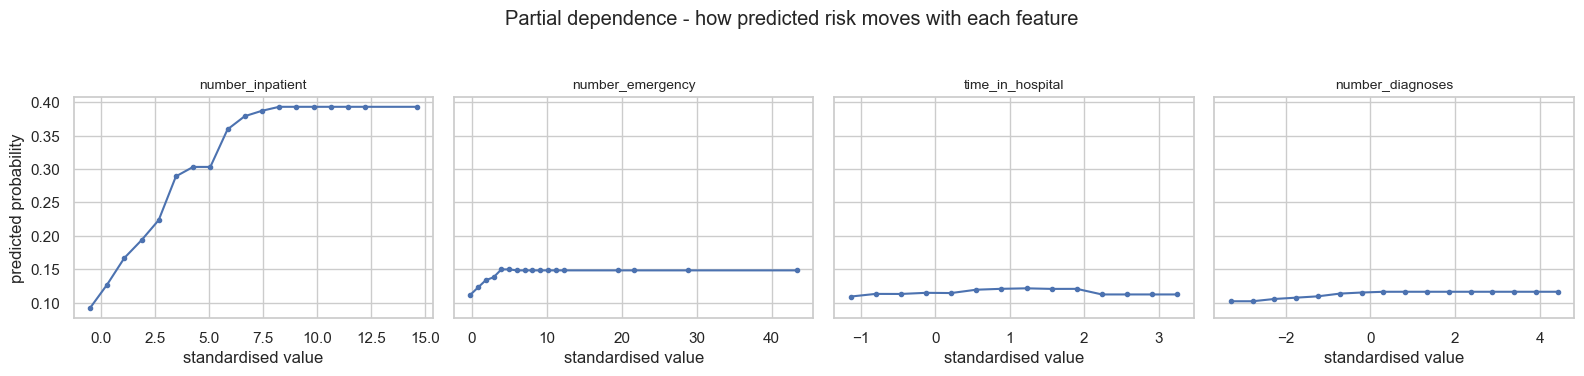

In [15]:
# Partial dependence for the strongest numeric features, to check the model learned the direction a clinician would expect
TOP_NUMERIC = ["number_inpatient", "number_emergency", "time_in_hospital", "number_diagnoses"]
positions = [list(feature_names).index(f"num__{f}") for f in TOP_NUMERIC]

fig, axes = plt.subplots(1, len(TOP_NUMERIC), figsize=(16, 3.6), sharey=True)

for ax, name, pos in zip(axes, TOP_NUMERIC, positions):
    # method="brute" forces the probability scale - the default "recursion" returns log-odds
    pd_result = partial_dependence(
        gb, X_test, features=[pos], kind="average",
        method="brute", response_method="predict_proba",
        grid_resolution=20,
    )
    ax.plot(pd_result["grid_values"][0], pd_result["average"][0], marker="o", ms=3)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("standardised value")

axes[0].set_ylabel("predicted probability")
plt.suptitle("Partial dependence - how predicted risk moves with each feature", y=1.04)
plt.tight_layout()
plt.show()

### My reading: is the model behaving the way a clinician would expect?

Mostly yes, and the one place it looks odd turns out to be defensible.

Prior admissions behaves exactly as I would want. Predicted risk starts at about 9% for a patient with no admissions in the past year and climbs steeply to around 39% by five or six, then flattens completely. That is the right shape. On a ward, the difference between a patient who has not been admitted this year and one who has been in three times is enormous. The difference between eight admissions and twelve is nothing: both are people whose lives are organised around the hospital, and there is no further worry left to add. A model that kept rising would be telling me something I do not believe. A model that saturates is telling me it has learned where the clinical information runs out.

Prior emergency visits does the same thing, but it saturates almost immediately, within about three visits, and at a much lower ceiling of roughly 15%. Again that matches how I would think. One or two emergency presentations in a year is a meaningful signal; after that the patient is already in the higher-risk group and each further visit adds little. The lower ceiling relative to inpatient admissions is also right. Being admitted says more than attending and being sent home.

Length of stay is the one that looked wrong at first. It is almost flat, moving between about 11% and 12% across its entire range, with a slight rise and then a fall at the long end. I would have expected a longer admission to mean a sicker patient and therefore a higher risk of return. The reason it does not is worth stating. Length of stay is not a severity measure. It confounds two opposite things: patients who stay a long time because they are very unwell, and patients who stay a long time because discharge planning is slow, a placement is being arranged, or someone is waiting for a family decision. The second group is often being held precisely so that they can be discharged safely, which lowers their risk of coming back. The two effects work against each other and the curve flattens. I am satisfied that this is the model reflecting the data honestly rather than failing to find an effect.

Number of diagnoses rises gently, from about 10% to 12%, and then flattens. Comorbidity burden matters, but it matters a lot less than whether the patient has actually been back before. Behaviour rather than problem list. That is consistent with everything else in this project.

Now that these are on the probability scale, the comparison is easy to state. One variable moves the prediction across a thirty-point range. The other three move it across two or three points between them. That is the permutation result seen a different way, and what I take from it clinically is that the model has learned a real and sensible rule, and that the rule is one a registrar already applies from memory. Which is the whole difficulty with this project, and the reason the comparison in notebook 05 mattered so much.red so much.

---
## 6. Risk tiers, rebuilt

Notebook 04 proposed two tiers — a high tier above 0.25 getting the full bundle, and
a middle tier from 0.125 to 0.25 getting a 72-hour phone call — on the reasoning
that intervention intensity should match confidence. Section 5 of that notebook then
undermined it: the top band over-predicted in most groups, so the patients I would
have spent most on were the ones the model was least accurate about.

Boosting's top band is exact in aggregate. Whether the tiers are viable now depends
entirely on what section 3 above found, so this section should only be taken
seriously if the subgroup calibration came back clean.

I am also dropping the 0.25 boundary. It was chosen because precision crossed 30%
there, which is a modeller's reason rather than a clinical one. Defining tiers by
the share of discharges they cover is more useful to a service planning its week.

In [13]:
# Define tiers by the share of discharges each covers, rather than by a probability boundary picked off a table
HIGH_SHARE, MID_SHARE = 0.05, 0.28

sorted_desc = np.sort(prob_gb)[::-1]
cut_high = float(sorted_desc[int(HIGH_SHARE * len(prob_gb)) - 1])
cut_mid  = float(sorted_desc[int(MID_SHARE * len(prob_gb)) - 1])

tier = np.where(prob_gb >= cut_high, "high",
        np.where(prob_gb >= cut_mid, "middle", "standard"))

rows = []
for t in ["high", "middle", "standard"]:
    m = tier == t
    n, ev = int(m.sum()), int(y_test[m].sum())
    lo, hi = proportion_confint(ev, n, alpha=0.05, method="wilson")
    rows.append({"tier": t, "n": n, "share_%": round(100 * n / len(y_test), 1),
                 "readmissions": ev,
                 "observed_rate_%": round(100 * ev / n, 1),
                 "95% CI": f"{100*lo:.1f}-{100*hi:.1f}",
                 "mean_predicted_%": round(100 * prob_gb[m].mean(), 1),
                 "share_of_all_readmissions_%": round(100 * ev / y_test.sum(), 1)})

print(f"High tier:   probability >= {cut_high:.4f}")
print(f"Middle tier: probability >= {cut_mid:.4f}\n")
print(pd.DataFrame(rows).to_string(index=False))

High tier:   probability >= 0.2403
Middle tier: probability >= 0.1286

    tier     n  share_%  readmissions  observed_rate_%    95% CI  mean_predicted_%  share_of_all_readmissions_%
    high   981      5.0           316             32.2 29.4-35.2              31.9                         14.5
  middle  4516     23.0           753             16.7 15.6-17.8              17.0                         34.6
standard 14137     72.0          1110              7.9   7.4-8.3               8.1                         50.9


### My reading: do these tiers separate patients usefully enough to act on?

Yes, with one caveat I have to be honest about.

The separation is real. The high tier runs at 32.2% and the standard tier at 7.9%, a fourfold difference, and the confidence intervals are nowhere near each other. The middle tier sits cleanly between them at 16.7%. Three groups, genuinely distinct, and the ordering holds. If I hand a ward a list split this way, the top group really is about four times more likely to come back than the bottom group.

The part that matters more to me is that the tiers are calibrated. The high tier predicts 31.9% and observes 32.2%. The middle predicts 17.0% and observes 16.7%. Both are inside their intervals. This is the specific thing that failed in notebook 04, where the top band over-predicted almost everywhere and the patients the model was most confident about were the ones it was most wrong about. I shelved the tiered design because of it. On this model the problem is gone, which is what lets me put the design back on the table rather than abandoning it.

Calibration is what makes a tier actionable rather than decorative. A nurse being told a patient is high risk needs that to mean something stable. "About a third of these patients will be back within the month" is a statement someone can plan around and can later check. A tier that says high and delivers a quarter teaches people to ignore it, and they only need to learn that once.

The sizes also work operationally. Five percent in the high tier is 981 patients out of 19,634, which at ward scale is a handful per week. That is small enough to give the full discharge bundle to. The middle tier at 23% is too large for intensive input but about right for something cheap, a follow-up phone call within seventy-two hours. The intensity of the intervention can match the confidence of the prediction, which was the original argument for tiering rather than a single flag.

Now the caveat, and it is the one a reviewer will go to first. The high tier holds only 14.5% of all readmissions. Half of them are in the standard tier, the group I am proposing to do nothing extra for. That is not a flaw in the tiering, it is the base rate doing its work: 72% of patients are in the standard tier, so even at a low rate of 7.9% they contribute the largest absolute number of returns. But it means this is a prioritisation tool and nothing more. It tells a ward where to spend scarce attention first. It does not tell them who is safe, and any presentation of these tiers that lets someone read the standard tier as "low risk, no action" would be a misuse of it. One in thirteen of those patients is coming back.

The last thing I would say is that the tier boundaries are still mine rather than the data's. 0.2403 and 0.1286 come from a review budget I chose, not from anything intrinsic in the distribution. A facility with more capacity should move them, and the right way to set them is to start from how many patients can actually be worked up in a week and solve backwards, which is what I did here.

## 7. A note for the discharge team

**What the flag means**

Every patient gets a risk tier at discharge. It is built from their record: mostly how many times they have been admitted in the past year, and where they are being discharged to.

- **High** (about 1 in 20 patients): roughly 1 in 3 of these patients will be readmitted within 30 days.
- **Middle** (about 1 in 4 patients): roughly 1 in 6.
- **Standard** (about 7 in 10 patients): roughly 1 in 13.

Those numbers are what the model was measured at, not what it hopes for. If you flag a hundred high-tier patients this month, expect around thirty of them back.

**What the flag does not mean**

It is not a diagnosis and it is not a prediction about the patient in front of you. It is a way of ordering a list when you cannot give everyone the same attention.

Four things it cannot do.

It does not find most readmissions. Half of the patients who come back are in the standard tier. Standard means lower risk, not safe. One in thirteen of them is still back within a month.

It does not know anything you do not. The two things driving it, prior admissions and discharge destination, are already in the notes. If you have read the chart, you have seen what the model has seen. It is faster and more consistent than doing it in your head, and that is all.

It cannot see the things that usually decide this. Whether the patient can afford next month's medication, get to a follow-up appointment, or has someone at home helping them. None of that is recorded anywhere, so none of it reaches the model.

It has known blind spots. It understates risk in patients in their twenties, who in this population are mostly young type 1 diabetics whose control has slipped. It is weakest in patients over ninety, who are also the group most likely to return. In both cases, your judgement should override it.

**What to do when it fires**

High tier: the full discharge bundle. Confirm the patient or carer can describe the medication plan back to you. Check they can get the drugs and afford them. Confirm a follow-up date and that they can physically get there. Name who to call if things deteriorate.

Middle tier: a phone call within 72 hours. Are they taking the medication, did anything change, do they know when they are next seen.

Standard tier: normal discharge. No change to what you already do.

**The rule that overrides all of it**

If you are worried about a patient the model has not flagged, treat them as high risk. Your judgement is not the backup here. The model is.

---
## 8. Would this transfer to a Kenyan setting?

### My answer

No. Not the model, and not the question it was built to answer.

The fitted object does not transfer: half of it runs degraded because prior admissions cannot be counted across facilities, and a quarter of it does not run at all because the discharge destinations it leans on do not exist here. The outcome transfers worse still, because a readmission I never observe is recorded as a patient who did well, and the patients I am most likely to miss are the ones who could not afford to come back. And even if both of those were solved, the budget sweep says a facility reviewing a handful of patients a week is operating in exactly the range where this model beats counting prior admissions by the least.

What does transfer is the method. Every decision in these six notebooks, who belongs in the cohort, what the label actually measures, whether the probabilities mean what they claim, whether the thing works equally well for every group, and whether it beats what staff already do, applies unchanged to a different outcome in a different health system. That is the transplantable part, and the honest version of this section is that I am carrying the method across and leaving the model behind.

The four questions below are how I get to that answer.



**1. What would have to be true about the data for this model to run at all?**

Two variables carry 77% of this model, so the question is really about those two.

Prior inpatient admissions is 50% on its own. To compute it I need a patient identifier that persists across visits and a way to retrieve twelve months of prior encounters at the point of discharge. Within a single facility that is sometimes possible; the number exists in an outpatient register or in the EMR if the patient has been entered consistently. Across facilities it does not exist at all, because there is no unified patient identifier. A patient admitted three times this year at three different hospitals has a prior-admission count of one everywhere. The single strongest predictor in this model is therefore not missing in a Kenyan record so much as systematically understated, and understated most for exactly the patients who move between facilities looking for care they can afford.

Discharge disposition is 27%. This one does not survive at all. The levels doing the work here are home health service, skilled nursing facility, rehabilitation unit, transfer to another inpatient facility. A Kenyan district or county hospital has none of those. Almost every patient goes home. A variable with one value carries no information, so a quarter of this model disappears the moment it crosses the border. That is worth sitting with, because discharge destination was the one place in this dataset where functional status and social support were captured, however crudely. The setting that most needs those variables is the setting where even the proxy is gone.

The rest is more tractable than I expected. Diagnoses exist, though coded in ICD-10 rather than ICD-9, so the grouping logic from notebook 02 would have to be rebuilt. Length of stay, number of medications and number of diagnoses are all derivable from an inpatient file. Payer code has a local analogue in SHA coverage status, and I would expect it to carry a stronger gradient here than in the US data, not a weaker one, because the consequences of being uninsured are more immediate. Glucose is measured routinely; HbA1c much less so, though the permutation result suggests I am not losing much there.

So the honest answer to question one is that the model cannot be transplanted. Half of it would run degraded and a quarter of it would not run at all. What transfers is the method, not the fitted object.

**2. What would the outcome even mean, given that readmission is partly a measure of access?**

Less than it means here, and it means less here than I assumed when I started.

In this dataset a readmission is observed only if it happened inside the same hospital network. I raised that in notebook 01 as a boundary problem and then tested it: readmission rates rose with destination acuity, so there was no evidence of severe under-capture. In a Kenyan setting I could not run that test, and I would expect the answer to be different. A patient who deteriorates after discharge has several paths, and only one of them produces a recorded readmission at my facility. They might present to a different hospital, with no shared record. They might not present at all, because the fare is more than they have. They might die at home. Every one of those is recorded as a negative.

That makes the negative class mean something quite different. Here it mixes true non-returners with slow returners. There it would mix true non-returners, slow returners, patients who went elsewhere, patients who could not afford to come back, and patients who died. A model trained on that label would learn, in part, to predict who has the means to return. It would assign lower risk to the poorest patients, not because they do better but because their deterioration is invisible. That is the most serious problem in this entire section and it is not fixable by collecting more features. It is a property of the outcome.

There is also no reason the thirty-day window should be thirty days. That number comes from Medicare's readmission penalty, an administrative artefact I have already flagged. There is no equivalent penalty here. What actually structures return locally is the one-month clinic review and the point at which the discharge medication supply runs out. If I were setting a window, I would set it against one of those.

**3. Given the budget sweep, is a model the right answer at a facility reviewing a handful of patients a week?**

No, and this is the conclusion I least expected to reach.

The budget sweep in notebook 05 inverted what I assumed. The model's advantage over simply counting prior admissions grows with the size of the review budget: 25 extra patients caught at a 2% budget, 96 at 27.9%, 158 at 60%. The reason is straightforward once you see it. At a tight budget you are picking the most extreme patients, and being extreme largely is having a high prior-admission count. The model only earns its keep in the murky middle, where several weak signals have to be combined. Scarce capacity means a tight budget, and a tight budget is precisely where the model adds least.

A ward reviewing five patients a week gets most of the available benefit from a nurse counting previous admissions in the notes. That is not a rhetorical concession, it is what the numbers say.

One check I still owe before I let this stand. I have been comparing absolute gains, and at a 2% budget the absolute numbers are small for every method. The proportional comparison might read differently: 25 extra catches out of a small total could be a larger relative improvement than 96 out of a large one. I have not run that, and until I do, the strong version of this claim is not fully earned. I am stating the conclusion I hold now and marking the test that could qualify it.

**4. If not a model, what would you build instead?**

Three things, in order.

First, a data capture instrument rather than a predictive one. Five structured fields at discharge: can the patient afford next month's medication, how far do they live from the facility and can they cover the fare, is there someone at home who can help, is there a phone number that will actually be answered, and can the patient or carer repeat the plan back. That is perhaps ninety seconds of nurse time. None of those fields exists in this dataset, and between them they plausibly account for a large part of the ceiling I spent five notebooks running into. Nothing worth modelling can be built until they exist, and that is the point I keep arriving at from different directions: interoperability moves the data we already collect, but it cannot manufacture variables nobody ever recorded. The decision about what to capture is made at the bedside, in the design of the form, not downstream in the analysis.

Second, a rule rather than a model, deployable now. Two or more admissions in the past twelve months, or discharged on insulin without a confirmed follow-up date, triggers the discharge bundle. A human can compute it, it needs no infrastructure, it is auditable, and on the evidence from notebook 05 it captures most of what my model would have captured at realistic review volumes. The model's remaining advantage over a rule is governance rather than accuracy: a calibrated probability can be thresholded, tiered and audited for subgroup bias, while a rule of thumb applied informally cannot. That is a real advantage, but it is an argument for writing the rule down, not for deploying a model.

Third, change the outcome. Readmission is the wrong target locally because it is partly a measure of access. Loss to follow-up at the one-month review is observable from the facility's own appointment register, requires no cross-facility linkage, is actionable by the same team with the same phone call, and is the thing that actually goes wrong in chronic disease care here. The whole pipeline in these six notebooks transfers to it directly: cohort definition, label integrity, calibration, subgroup checks, comparison against a heuristic. The method is what travels.

That reframing is also where this project meets the work I am doing at Infarmatech, and it is the reason I think the deliverable from six notebooks of modelling is not a model at all. It is a specification of what a facility would need to record, and which question it should be asking, before a model is worth anyone's time.

## 9. What should be collected instead

Everything above tells me the record is the limiting factor. This section is my attempt to say what I would actually do about it, because "we need better data" is not a recommendation anyone can act on.

### Two different problems, two different fixes

The missing information in this project falls into two kinds, and they get blurred together constantly.

The first is a documentation problem. Fields that exist on the form and are left blank. Weight was missing in 96.9% of encounters here, and weight is a genuine predictor. Nobody decided not to collect it. It just never got entered. That is fixable with form design, training, and audit, and it costs nothing but attention.

The second is a health system problem. Determinants that are not collected anywhere, by anyone, on any form. Whether the patient can afford next month's medication. Whether they can physically reach a follow-up clinic. Whether there is anyone at home. No amount of diligence at the bedside fixes that one, because there is nowhere to write it down.

I keep seeing these two treated as the same complaint. They are not, and the second is the harder and more interesting one.

### Interoperability is not the answer to the second problem

Connecting systems moves data that already exists. It is genuinely important, and it would fix a real problem in this project: I cannot count a patient's prior admissions across facilities because there is no shared identifier. That is an interoperability failure and interoperability would solve it.

But it cannot manufacture information nobody ever recorded. If affordability was never asked at the bedside, no integration layer will surface it later. The two problems get discussed as though they were one, and the second one quietly never gets addressed.

### What I would add to the discharge form

Five fields, asked by whoever is discharging the patient. My estimate is ninety seconds.

1. Can the patient afford next month's medication? Yes, partly, no, unknown.
2. How far do they live from this facility, and can they cover the fare to return? A distance band and a yes or no.
3. Is there someone at home who can help with medication or get them back here? Yes, no, unsure.
4. A phone number that will be answered, and whose phone it is.
5. Can the patient or carer repeat the plan back? Yes, partly, no.

None of these exists in the dataset I have been working with. Each of them is a plausible candidate for the ceiling I spent five notebooks hitting, and each is something a nurse already knows informally by the time the patient leaves.

I am not claiming these five are the right five. I am claiming this is the form the argument has to take before anyone can act on it. "Capture social determinants" is a slogan. Five fields, a defined response set, a named person to record them, and a time cost is a proposal a facility can pilot and a county can evaluate.

### How I would know whether it worked

The honest test is not whether the model improves. It is whether the fields get filled in at all. A variable recorded for 20% of patients is not a variable, as weight demonstrated. So the first evaluation is completeness over three months, and only then whether the fields predict anything.

If they do not predict, that is still worth knowing and worth publishing, because the assumption that social determinants dominate clinical variables is something I believe and have not proved.

### Why this is the deliverable

The quality of prediction in our settings will depend less on the models we build than on the realities we choose to document at the point of care. That decision gets made when a form is designed, by clinicians and informaticians, not by analysts downstream working with whatever they were handed.

Which is why I think the output of six notebooks of modelling is not a model. It is a specification of what a facility would need to start recording, and which question it should be asking, before a model is worth anyone's time. That specification is the thing I intend to take further.

## 10. Summary

### What I built

A model that ranks diabetic inpatients at discharge by how likely they are to be back within thirty days, and a three-tier output built on top of it.

Set to flag the top 28% of discharges, which on this test set is 5,486 of 19,634 patients, it catches 1,067 of the 2,179 who actually came back. That is just under half. It misses 1,112 of them. Of the patients it flags, about one in five returns, so a ward following this list works up roughly five patients for every readmission it catches.

The comparison that matters is not against nothing. It is against what a registrar could do by reading the notes: sort by how many times the patient has been admitted in the past year, start at the top. That rule catches 972 patients at the same review budget. My model catches 1,067. Ninety-five more, and a bootstrap puts that gain between 57 and 137, so it is real rather than noise.

Ninety-five patients out of 19,634 discharges. That is what six notebooks of work buys over one number already written in the chart.

### What the project actually found

The finding is not the model. It is that the ceiling is in the data, and I have four independent pieces of evidence for it.

Strip the model from thirty-seven features to six and it performs the same: 1,009 catches against 1,019, a difference the bootstrap cannot distinguish from zero. Permute each variable in turn and two of them carry 77% of the model, with six variables contributing exactly nothing and six scoring slightly negative. Rank patients by prior inpatient admissions alone and you get an AUC of 0.617 against the full model's 0.670. And the model discriminates worst, at 0.601, in patients over ninety, who are the group most likely to come back.

That last one is the whole argument in miniature. For a patient in their thirties, whether they return is largely a question of disease control and admission history, and the record holds that. For a patient in their nineties it turns on whether they can manage their own medication, whether anyone at home is helping, whether they can afford the next prescription, whether they can physically get to a follow-up appointment. None of that is in the file. The model is not failing to find the answer. The answer was never there to find.

The most informative social signal in the entire dataset was discharge destination, which is not a measurement of the patient at all. It is a note of where they went and who would be caring for them. It did a quarter of the work.

### What I would do next

Three tiers, in ascending order of what they would buy and of how hard they are.

Algorithmic gains are marginal and I would not spend time there. Gradient boosting over logistic regression bought 51 catches. A better-tuned boosting model, or a stacked ensemble, might buy a few more. This is the tier everyone reaches for first and it is the one with the least left in it.

Data the EHR already holds but this extract does not is where I would actually look. Vital signs, especially the last set before discharge. Renal function and albumin. The discharge medication list as a list rather than a count. Whether a follow-up appointment was booked before the patient left. All of this exists in a hospital system somewhere; it simply was not in the file I was given. My expectation is that this tier moves the model more than anything algorithmic would, though I cannot prove it from here.

Data nobody collects is the tier that would matter most and the only one that requires changing what happens at the bedside rather than what happens in the analysis. Social circumstances, affordability, transport, whether there is a carer, whether follow-up actually happened. Section 9 sets out the five fields I would add and how I would test them.

### And a Kenyan version

It would not be this model and it would not be this question.

Half of what drives the model here degrades badly, because prior admissions cannot be counted across facilities without a shared patient identifier. A quarter of it disappears, because the discharge destinations doing the work, skilled nursing, rehabilitation, home health, do not exist. And readmission itself is the wrong target, because a patient who deteriorates and cannot afford the fare back is recorded as a patient who did well. The outcome would partly be measuring access.

Loss to follow-up at the one-month review is the target I would build for instead. It is observable from the facility's own appointment register with no cross-facility linkage, it is actionable by the same staff with the same phone call, and it is what actually goes wrong in chronic disease care here.

Everything in these six notebooks transfers to that question unchanged: how the cohort gets defined, what the label really measures, whether the probabilities mean what they claim, whether the thing works equally well for every group, and whether it beats what staff already do without it. The method travels. The model does not.

I set out to build a readmission model. What I have is a specification of what a hospital would need to start recording, and which question it should be asking, before a model is worth anyone's time. That is a more useful deliverable than an accuracy score, and it is the one I did not expect.score, and it is the one I did not expect.score, and it is the one I did not expect.